In [1]:
import matplotlib.pylab as plt
%matplotlib inline

import numpy as np
import numpy.typing as npt
import healpy as hp
import rubin_scheduler.scheduler.basis_functions as bf
import rubin_scheduler.scheduler.detailers as detailers
from rubin_scheduler.scheduler.surveys import GreedySurvey
from rubin_scheduler.scheduler.utils import (
    ConstantFootprint,
    Footprints,
    ecliptic_area,
)
from rubin_scheduler.site_models import Almanac, CloudMap
from rubin_scheduler.utils import DEFAULT_NSIDE, SURVEY_START_MJD
from rubin_scheduler.scheduler.utils import (
    CurrentAreaMap,
    Footprint,
    ScheduledObservationArray,
    make_rolling_footprints,
)
from rubin_scheduler.scheduler.schedulers import CoreScheduler
from astropy.time import Time
from rubin_scheduler.scheduler.model_observatory import ModelObservatory
from rubin_scheduler.scheduler import sim_runner

In [2]:
# Set the survey start time. Presumably we will change this to when we have cloud data
SURVEY_START_MJD = Time("2026-02-24T12:00:00").mjd
nside = 32

In [3]:
# Quick copy-paste so we can generate our current standard survey footprint.
def standard_survey_footprint(survey_start_mjd=SURVEY_START_MJD, nside=32, nslice=2,
                              rolling_scale=0.9, rolling_uniform=True):
    # Generate footprint over the sky
    sky = CurrentAreaMap(nside=nside)
    footprints_hp_array, labels = sky.return_maps()
    # Identify pixels for rolling
    roll_indx = np.where((labels == "lowdust") | (labels == "virgo"))[0]
    roll_footprint = footprints_hp_array["r"] * 0
    roll_footprint[roll_indx] = 1

    footprints_hp = {}
    for key in footprints_hp_array.dtype.names:
        footprints_hp[key] = footprints_hp_array[key]

    # Set up a mask to contain some surveys within this region
    footprint_mask = footprints_hp["r"] * 0
    footprint_mask[np.where(footprints_hp["r"] > 0)] = 1

    # Use the Almanac to find the position of the sun at the start of survey
    almanac = Almanac(mjd_start=survey_start_mjd)
    sun_moon_info = almanac.get_sun_moon_positions(survey_start_mjd)
    sun_ra_start = sun_moon_info["sun_RA"].copy()

    # Define the rolling footprint
    footprints = make_rolling_footprints(
        fp_hp=footprints_hp,
        mjd_start=survey_start_mjd,
        sun_ra_start=sun_ra_start,
        nslice=nslice,
        scale=rolling_scale,
        nside=nside,
        wfd_indx=roll_indx,
        order_roll=1,
        n_cycles=3,
        uniform=rolling_uniform,
    )

    return footprints

In [4]:
# Taken from https://github.com/lsst-sims/sims_featureScheduler_runs5.2/blob/main/comp_survey/lsst_surveys.py

# Set up values to use as kwarg defaults.
NEXP = 1
U_NEXP = 1
EXPTIME = 30.0
U_EXPTIME = 38.0
GOOD_SEEING_MAX = 1.3
CAMERA_ROT_LIMITS = (-80.0, 80.0)
SCIENCE_PROGRAM = "BLOCK-407"

def safety_masks(
    nside: int = DEFAULT_NSIDE,
    moon_distance: float = 30,
    wind_speed_maximum: float = 20.0,
    min_alt: float = 20,
    max_alt: float = 86.5,
    min_az: float = 0,
    max_az: float = 360,
    shadow_minutes: float = 70,
    min_az_sunrise: float = 120,
    max_az_sunrise: float = 290,
    time_to_sunrise: float = 3.0,
    apply_time_limited_shadow: bool = True,
    sun_alt_limit: float | None = None,
) -> list[bf.BaseBasisFunction]:
    """Basic safety mask basis functions.

    Avoids the moon, bright planets, high wind, and
    areas on the sky out of bounds, using
    the MoonAvoidanceBasisFunction, PlanetMaskBasisFunction,
    AvoidDirectWindBasisFunction, and the AltAzShadowMaskBasisFunction.
    Adds the default AltAzShadowMaskTimeLimited basis function to avoid
    pointing toward sunrise late in the night during commissioning.

    Parameters
    ----------
    nside : `int` or None
        The healpix nside to use.
        Default of None uses rubin_scheduler.utils.get_default_nside.
    moon_distance : `float`, optional
        Moon avoidance distance, in degrees.
    wind_speed_maximum : `float`, optional
        Wind speed maximum to apply to the wind avoidance basis function,
        in m/s.
    min_alt : `float`, optional
        Minimum altitude (in degrees) to observe.
    max_alt : `float`, optional
        Maximum altitude (in degrees) to observe.
    min_az : `float`, optional
        Minimum azimuth angle (in degrees) to observe.
    max_az : `float`, optional
        Maximum azimuth angle (in degrees) to observe.
    shadow_minutes : `float`, optional
        Avoid inaccessible alt/az regions, as well as parts of the sky
        which will move into those regions within `shadow_minutes` (minutes).
        Should be set to the expected time needed to execute the
        observing block associated with the survey.
    min_az_sunrise : `float`, optional
        Minimum azimuth angle (in degrees) to observe during time period
        at the end of the night (during time_to_sunrise).
    max_az_sunrise: `float`, optional
        Maximum azimuth angle (in degrees) to observe during the time period
        at the end of the night (during time_to_sunrise).
    time_to_sunrise : `float`, optional
        Hours before daybreak (sun @ alt=0) to start the azimuth avoidance
        mask.
    apply_time_limited_shadow : `bool`, optional
        Flag for whether to apply the morning (time_to_sunrise) azimuth mask.
    sun_alt_limit : `float` or None, optional
        Maximum sun altitude (deg) required before proposing targets.

    Returns
    -------
    mask_basis_functions : `list` [`BaseBasisFunction`]
        Mask basis functions should always be used with a weight of 0.
        The masked (np.nan or -np.inf) regions will remain masked,
        but the basis function values won't influence the reward.
    """
    mask_bfs = []
    # Avoid the moon - too close to the moon will trip the REBs
    mask_bfs.append(
        bf.MoonAvoidanceBasisFunction(nside=nside, moon_distance=moon_distance)
    )
    # Avoid bright planets
    mask_bfs.append(bf.PlanetMaskBasisFunction(nside=nside))
    # Avoid the wind
    mask_bfs.append(
        bf.AvoidDirectWind(nside=nside, wind_speed_maximum=wind_speed_maximum)
    )
    # Avoid the alt/az limits - this will pick up limits from the
    # yaml file configurations for the summit as well
    mask_bfs.append(
        bf.AltAzShadowMaskBasisFunction(
            nside=nside,
            min_alt=min_alt,
            max_alt=max_alt,
            min_az=min_az,
            max_az=max_az,
            shadow_minutes=shadow_minutes,
        )
    )

    if apply_time_limited_shadow:
        # Only look away from the azimuth of the sun in the next day
        # permitting emergency dome closure
        mask_bfs.append(
            bf.AltAzShadowTimeLimitedBasisFunction(
                nside=nside,
                min_alt=min_alt,
                max_alt=max_alt,
                min_az=min_az_sunrise,
                max_az=max_az_sunrise,
                shadow_minutes=shadow_minutes,
                # Time until/after sun_keys in hours
                time_to_sun=time_to_sunrise + shadow_minutes / 60.0,
                # 'sunrise' is 0 degree sunrise
                sun_keys=["sunrise"],
            )
        )

    if sun_alt_limit is not None:
        mask_bfs.append(bf.SunAltLimitBasisFunction(alt_limit=sun_alt_limit))

    return mask_bfs


def standard_bf(
    nside: int = DEFAULT_NSIDE,
    bandname: str = "g",
    bandname2: str | None = "i",
    m5_weight: float = 6.0,
    footprint_weight: float = 1.5,
    slewtime_weight: float = 3.0,
    stayband_weight: float = 3.0,
    footprints: Footprints | None = None,
    fiducial_fwhm: float = 1.3,
    season: float = 365.25,
    season_start_hour: float = -4.0,
    season_end_hour: float = 2.0,
    strict: bool = True,
    seeing_fwhm_max: float | None = None,
) -> list[tuple[bf.BaseBasisFunction, float]]:
    """Generate the standard basis functions that are shared by blob surveys

    Parameters
    ----------
    nside : `int`
        The HEALpix nside to use. Defaults to DEFAULT_NSIDE
    bandname : `str`
        The band name for the first observation. Default "g".
    bandname2 : `str`
        The band name for the second in the pair (None if unpaired).
        Default "i".
    m5_weight : `float`
        The weight for the 5-sigma depth difference basis function.
    footprint_weight : `float`
        The weight on the survey footprint basis function.
    slewtime_weight : `float`
        The weight on the slewtime basis function.
    stayband_weight : `float`
        The weight on basis function that tries to stay avoid band changes.
    footprints : `rubin_scheduler.scheduler.utils.Footprints` object
        The desired footprints object. Default of None will work, but is likely
        not desirable.
    fiducial_fwhm : `float`
        The fiducial FWHM for the M5Diff Basis function.
    n_obs_template : `dict`
        The number of observations to take every season in each band.
    season : `float`
        The length of season (i.e., how long before templates expire) (days).
        Default 365.25.
    season_start_hour : `float`
        Hour angle limits to use when gathering templates.
        Default -4 (hours)
    season_end_hour : `float`
       Hour angle limits to use when gathering templates.
       Default +2 (hours)
    strict : `bool`
        If False, use BandChangeBasisFunction which rewards visits in the
        same bandpass as currently in-use.
        If True, use a StrictBandBasisFunction which rewards visits in the
        same bandpass as currently in-use, but also rewards visits in
        different filters if the moon rose/set or twilight ended/started,
        or if there was a large gap in observing.
    seeing_fwhm_max : `float`
        Seeing limit to pass to the FootprintBasisFunction - visits
        with delivered image quality > seeing_fwhm_max will not be counted.

    Returns
    -------
    basis_functions_weights : `list`
        list of tuple pairs (basis function, weight) that is
        (rubin_scheduler.scheduler.BasisFunction object, float)

    """

    bfs = []

    if bandname2 is not None:
        bfs.append(
            (
                bf.M5DiffBasisFunction(
                    bandname=bandname, nside=nside, fiducial_FWHMEff=fiducial_fwhm
                ),
                m5_weight / 2.0,
            )
        )
        bfs.append(
            (
                bf.M5DiffBasisFunction(
                    bandname=bandname2, nside=nside, fiducial_FWHMEff=fiducial_fwhm
                ),
                m5_weight / 2.0,
            )
        )

    else:
        bfs.append(
            (
                bf.M5DiffBasisFunction(
                    bandname=bandname, nside=nside, fiducial_FWHMEff=fiducial_fwhm
                ),
                m5_weight,
            )
        )

    if bandname2 is not None:
        bfs.append(
            (
                bf.FootprintBasisFunction(
                    bandname=bandname,
                    footprint=footprints,
                    out_of_bounds_val=np.nan,
                    nside=nside,
                    seeing_fwhm_max=seeing_fwhm_max,
                ),
                footprint_weight / 2.0,
            )
        )
        bfs.append(
            (
                bf.FootprintBasisFunction(
                    bandname=bandname2,
                    footprint=footprints,
                    out_of_bounds_val=np.nan,
                    nside=nside,
                    seeing_fwhm_max=seeing_fwhm_max,
                ),
                footprint_weight / 2.0,
            )
        )
    else:
        bfs.append(
            (
                bf.FootprintBasisFunction(
                    bandname=bandname,
                    footprint=footprints,
                    out_of_bounds_val=np.nan,
                    nside=nside,
                    seeing_fwhm_max=seeing_fwhm_max,
                ),
                footprint_weight,
            )
        )

    bfs.append(
        (
            bf.SlewtimeBasisFunction(bandname=bandname, nside=nside),
            slewtime_weight,
        )
    )
    if strict:
        bfs.append((bf.StrictBandBasisFunction(bandname=bandname), stayband_weight))
    else:
        bfs.append((bf.BandChangeBasisFunction(bandname=bandname), stayband_weight))

    bandnames = [fn for fn in [bandname, bandname2] if fn is not None]
    bfs.append((bf.BandLoadedBasisFunction(bandnames=bandnames), 0))

    return bfs



def gen_greedy_surveys(
    nside: int = DEFAULT_NSIDE,
    bands: list[str] = ["r", "i", "z", "y"],
    ignore_obs: list[str] = ["DD", "twilight_near_sun", "ToO"],
    camera_rot_limits: tuple[float, float] = CAMERA_ROT_LIMITS,
    exptime: float = EXPTIME,
    nexp: int = NEXP,
    u_exptime: float = U_EXPTIME,
    u_nexp: int = U_NEXP,
    shadow_minutes: float = 15.0,
    max_alt: float = 76.0,
    m5_weight: float = 3.0,
    footprint_weight: float = 0.75,
    slewtime_weight: float = 3.0,
    stayband_weight: float = 100.0,
    repeat_weight: float = -1.0,
    footprints: Footprints | None = None,
    science_program: str = SCIENCE_PROGRAM,
    safety_mask_params: dict | None = None,
) -> list[GreedySurvey]:
    """Generate greedy (single-best choice visits) Surveys.

    Parameters
    ----------
    nside : `int`
        The HEALpix nside to use
    bands : `list` [ `str` ]
        Bands in which to generate greedy surveys.
        Default ['r', 'i', 'z', 'y'].
    ignore_obs : `str` or `list` of `str`
        Ignore observations by surveys that include the given substring(s).
    camera_rot_limits : `list` [ `float` ]
        The limits to impose when rotationally dithering the camera (degrees).
        Default [-80., 80.].
    exptime : `float`
        The exposure time for grizy visits.
    nexp : `int`
        The number of exposures per visit for grizy visits.
    u_exptime : `float`
        The exposure time for u band visits.
    u_nexp : `int`
        The number of exposures per visit for u band visits.
    shadow_minutes : `float`
        Used to mask regions around zenith (minutes).
    max_alt : `float`
        The maximium altitude to use when masking zenith (degrees).
    m5_weight : `float`
        The weight for the 5-sigma depth difference basis function.
    footprint_weight : `float`
        The weight on the survey footprint basis function.
    slewtime_weight : `float`
        The weight on the slewtime basis function.
    stayband_weight : `float`
        The weight on basis function that tries to stay avoid band changes.
    repeat_weight : `float`
        Weight that enhances (+ values) or decreases (- values) the likelihood
        of revisiting the same pointing within a two-hour time gap.
    footprints : `rubin_scheduler.scheduler.utils.footprints.Footprints`
        The footprints to be used for the long-gaps surveys.
    science_program : `str`
        The science_program to use for visits from these surveys.
    safety_mask_params : `dict` or None
        A dictionary of additional kwargs to mass to the standard safety masks.
    """
    # Define the extra parameters that are used in the greedy survey. I
    # think these are fairly set, so no need to promote to utility func kwargs
    greed_survey_params = {
        "block_size": 1,
        "smoothing_kernel": None,
        "seed": 42,
        "camera": "LSST",
        "dither": "night",
    }
    if safety_mask_params is None:
        safety_mask_params = {"nside": nside}
    else:
        safety_mask_params = copy.deepcopy(safety_mask_params)
    if (
        "shadow_minutes" not in safety_mask_params
        or safety_mask_params["shadow_minutes"] < shadow_minutes
    ):
        safety_mask_params["shadow_minutes"] = shadow_minutes

    surveys = []
    detailer_list = [
        detailers.CameraRotDetailer(
            min_rot=np.min(camera_rot_limits), max_rot=np.max(camera_rot_limits)
        )
    ]
    detailer_list.append(detailers.LabelRegionsAndDDFs())

    if "u" in bands:
        detailer_list.append(
            detailers.BandNexp(bandname="u", nexp=u_nexp, exptime=u_exptime)
        )

    for bandname in bands:
        bfs = []
        bfs.extend(
            standard_bf(
                nside,
                bandname=bandname,
                bandname2=None,
                m5_weight=m5_weight,
                footprint_weight=footprint_weight,
                slewtime_weight=slewtime_weight,
                stayband_weight=stayband_weight,
                footprints=footprints,
                strict=False,
            )
        )

        # XXX-magic numbers
        bfs.append(
            (
                bf.VisitRepeatBasisFunction(
                    gap_min=0, gap_max=2 * 60.0, bandname=None, nside=nside, npairs=20
                ),
                repeat_weight,
            )
        )
        # Masks, give these 0 weight
        bfs.append(
            (
                bf.AltAzShadowMaskBasisFunction(
                    nside=nside, shadow_minutes=shadow_minutes, max_alt=max_alt, pad=3.0
                ),
                0,
            )
        )

        masks = safety_masks(nside=nside, shadow_minutes=shadow_minutes)
        for m in masks:
            bfs.append((m, 0))

        weights = [val[1] for val in bfs]
        basis_functions = [val[0] for val in bfs]
        surveys.append(
            GreedySurvey(
                basis_functions,
                weights,
                exptime=exptime,
                bandname=bandname,
                nside=nside,
                ignore_obs=ignore_obs,
                nexp=nexp,
                detailers=detailer_list,
                survey_name=f"greedy {bandname}",
                science_program=science_program,
                observation_reason=f"singles_{bandname}",
                **greed_survey_params,
            )
        )

    return surveys

In [5]:
# Build a single-band greedy scheduler
footprint = standard_survey_footprint()
surveys = gen_greedy_surveys(bands=["r"], footprints=footprint)


In [6]:
# Make a cloud_maps object
cloud_maps = CloudMap()
# add a cloud frame
cloud_maps.add_frame(np.zeros(hp.nside2npix(nside)), SURVEY_START_MJD)

In [7]:
surveys

[<GreedySurvey survey_name='greedy r' at 0x177d1dbe0>]

In [8]:
scheduler = CoreScheduler(surveys, nside=nside)
# Model observatory, no downtime or closing for clouds.
mo = ModelObservatory(nside=nside, mjd_start=SURVEY_START_MJD, cloud_data="ideal", downtimes="ideal", cloud_maps=cloud_maps)


In [9]:
# Simulate 2 days of observations
mo, scheduler, observations = sim_runner(mo, scheduler,sim_duration=2.0, verbose=True)

progress = 33.31%

/Users/yoachim/git_repos/rubin_scheduler/rubin_scheduler/skybrightness_pre/sky_model_pre.py:401: UserWarning: Requested MJD between sunrise and sunset, returning closest maps
  warnings.warn("Requested MJD between sunrise and sunset, returning closest maps")


progress = 99.92%Skipped 0 observations
Flushed 0 observations from queue for being stale
Completed 2725 observations
ran in 3 min = 0.1 hours


Text(0, 0.5, 'dec (deg)')

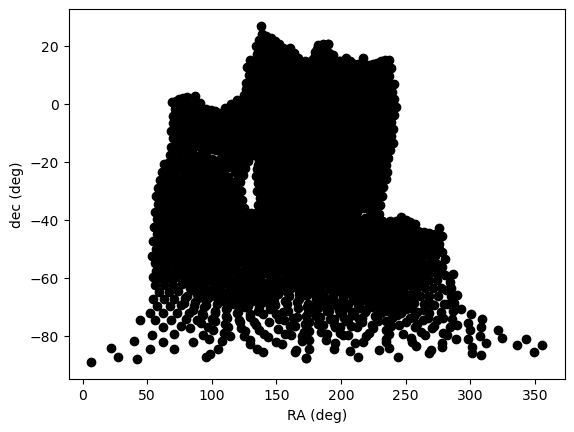

In [10]:
fig, ax = plt.subplots()
ax.plot(np.degrees(observations["RA"]), np.degrees(observations["dec"]), 'ko')
ax.set_xlabel("RA (deg)")
ax.set_ylabel("dec (deg)")